In [6]:
import numpy as np
import rasterio as rio

# Load the DEM
filename = "data/dems/lunargem_4to5_slope.tif"
with rio.open(filename) as dem:
    slope_dem = dem.read(1)  # Assuming the DEM is in the first band


In [2]:
import networkx as nx

# Create a directed graph
G = nx.DiGraph()

rows, cols = slope_dem.shape

# Function to add edges to the graph with weights calculated from the fitness function
def add_edges_with_weights(G, slope_dem, fitness_function):
    rows, cols = slope_dem.shape
    for i in range(rows):
        for j in range(cols):
            # Current node
            current_node = (i, j)
            # Define neighbors (8-connectivity)
            neighbors = [
                (i-1, j-1), (i-1, j), (i-1, j+1),
                (i, j-1),           (i, j+1),
                (i+1, j-1), (i+1, j), (i+1, j+1)
            ]
            for neighbor in neighbors:
                ni, nj = neighbor
                if 0 <= ni < rows and 0 <= nj < cols:
                    # Compute the weight using the fitness function
                    weight = fitness_function((i, j),(ni, nj),slope_dem)
                    # Add edge to the graph
                    G.add_edge(current_node, neighbor, weight=weight)


In [30]:
def fitness_function(step1, step2,slope_dem):
    if step1[0] != step2[0] & step1[1]!=step2[1]:
        x=np.sqrt(2)
    else:
        x=1
    speed1 = 0.025 - (0.001*slope_dem[step1[0]][step1[1]])
    speed2 = 0.025 - (0.001*slope_dem[step2[0]][step2[1]])
    speed = (speed1+speed2)/2
    if speed < 0.01:
        speed = 0.0001
    time_s = float(x/speed)

    return time_s  # Example fitness function: absolute difference in slope

# Add edges to the graph
add_edges_with_weights(G, slope_dem, fitness_function)


In [31]:
# Define start and end nodes
start_node = (120,84)  # Example start node
end_node = (266,282)  # Example end node

# Compute the shortest path
shortest_path = nx.dijkstra_path(G, start_node, end_node)
shortest_path_length = nx.dijkstra_path_length(G, start_node, end_node)

print("Shortest path:", shortest_path)
print("Shortest path length:", shortest_path_length)


Shortest path: [(120, 84), (119, 85), (118, 86), (117, 87), (116, 88), (115, 89), (114, 90), (113, 91), (112, 92), (111, 93), (110, 94), (109, 95), (108, 96), (107, 97), (106, 98), (105, 99), (104, 100), (103, 101), (102, 102), (103, 103), (104, 104), (105, 105), (106, 106), (107, 107), (108, 108), (109, 109), (110, 110), (111, 111), (112, 112), (113, 113), (114, 114), (115, 115), (116, 116), (117, 117), (118, 118), (119, 119), (120, 120), (121, 121), (122, 122), (123, 123), (124, 124), (125, 125), (126, 126), (127, 127), (128, 128), (129, 129), (130, 130), (131, 131), (132, 132), (133, 133), (134, 134), (135, 135), (136, 136), (137, 137), (138, 138), (139, 139), (140, 140), (141, 141), (142, 142), (143, 143), (144, 144), (145, 145), (146, 146), (147, 147), (148, 148), (149, 149), (150, 150), (151, 151), (152, 152), (153, 153), (154, 154), (155, 155), (156, 156), (157, 157), (158, 158), (159, 159), (160, 160), (161, 161), (162, 162), (163, 163), (164, 164), (165, 165), (166, 166), (167

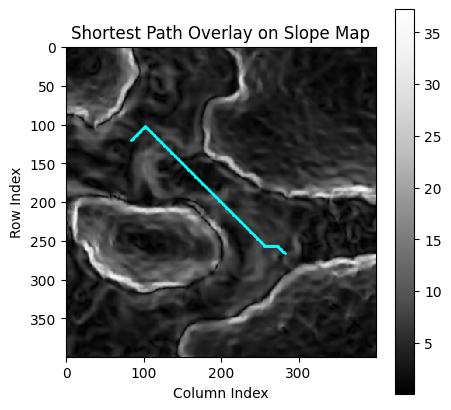

In [29]:
%matplotlib inline
import mpld3
from rasterio.plot import show
import matplotlib.pyplot as plt
mpld3.enable_notebook()
# Plotting
fig, ax = plt.subplots(1, figsize=(5, 5))

    # Plot slope map
ax.imshow(slope_dem, origin='upper', cmap='Greys_r', interpolation='none')

    # Extract x, y coordinates for path plotting
path_x = [point[1] for point in shortest_path]  # Col indices
path_y = [point[0] for point in shortest_path]  # Row indices

    # Plot path
ax.plot(path_x, path_y, marker='o', color='cyan', markersize=1, linewidth=0.5)

ax.set_title('Shortest Path Overlay on Slope Map')
ax.set_xlabel('Column Index')
ax.set_ylabel('Row Index')
ax.grid(False)
plt.colorbar(ax.imshow(slope_dem, origin='upper', cmap='Greys_r', interpolation='none'), ax=ax)

plt.show()

In [33]:
import BORAS_v1

t = BORAS_v1.calc_traverse_time(shortest_path,slope_dem)
d = BORAS_v1.calc_dist(shortest_path)
print(t)
print(d)

12130.138762781446
331.9655121145944
